# EDA on Diabetes data

In [ ]:
import os

import pandas as pd

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

#parameters for matplotlib and seaborn
pd.set_option('display.max_columns', None)
custom_params = {"axes.spines.right": False,
                  "axes.spines.top": False,
                #   "figure.figsize": (10, 6),
                  "axes.edgecolor": "#d3d3d3",
                  "font.family": "STIXGeneral",}

custom_colors = ["#1b4b99", "#1a9b38", "#c46d70"]
sns.set_theme(style="white", rc=custom_params, palette=custom_colors)
sns.set_context('notebook', font_scale=1.2)
%matplotlib inline

In [ ]:
def create_bar_chart(
    data: pd.DataFrame,
    x: str,
    y: str,
    title: str,
    xlabel: str,
    ylabel: str,
    hue: str = None,
):
    '''creates a bar chart using seaborn'''
    ax = sns.barplot(data=data, x=x, y=y, hue=hue)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

    for bar in ax.containers:
        ax.bar_label(bar, fmt='{:,.1%}', fontsize=8)
        ax.set_yticklabels(['{:,.1%}'.format(tick) for tick in ax.get_yticks()])

    return ax

In [ ]:
def create_histogram(
    data: pd.DataFrame,
    x: str,
    title: str,
    xlabel: str,
    ylabel: str,
    bins: int = 10,
):
    '''creates a histogram using seaborn'''
    ax = sns.histplot(data=data, x=x, bins=bins)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

    return ax


In [ ]:
FILENAME = os.path.join('..', 'data', 'diabetes_012_health_indicators_BRFSS2015.csv')

data = pd.read_csv(FILENAME)
data.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [ ]:
#standardize column names to lowercase
data.columns = data.columns.str.lower()

target_column = 'diabetes_012'

print(data[target_column].value_counts(normalize=True))

#Categorical columns
cat_cols = ['highbp', 'highchol', 'cholcheck', 'smoker', 'stroke',
            'heartdiseaseorattack', 'physactivity', 'fruits', 'veggies',
            'hvyalcoholconsump', 'anyhealthcare', 'nodocbccost', 'diffwalk',
            'sex']

cont_cols = [col for col in data.columns if col not in cat_cols + [target_column]]

diabetes_012
0.0    0.842412
2.0    0.139333
1.0    0.018255
Name: proportion, dtype: float64


In [ ]:
data.isnull().sum().sort_values(ascending=False)

diabetes_012            0
highbp                  0
highchol                0
cholcheck               0
bmi                     0
smoker                  0
stroke                  0
heartdiseaseorattack    0
physactivity            0
fruits                  0
veggies                 0
hvyalcoholconsump       0
anyhealthcare           0
nodocbccost             0
genhlth                 0
menthlth                0
physhlth                0
diffwalk                0
sex                     0
age                     0
education               0
income                  0
dtype: int64

<Axes: title={'center': 'Proportion of Diabetes Status'}, xlabel='Diabetes Status', ylabel='Proportion'>

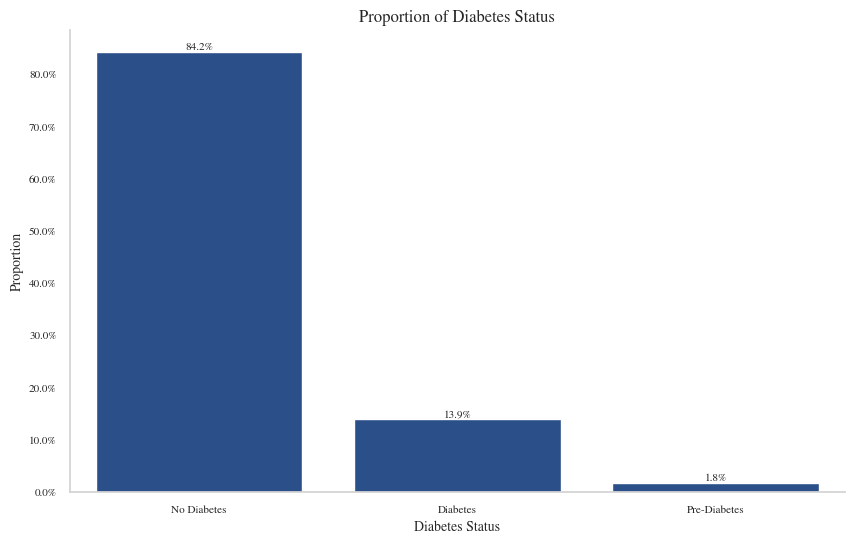

In [ ]:
daibetes_df = (data[target_column]
               .value_counts(normalize=True)
               .reset_index()
               .replace({target_column: {0: 'No Diabetes', 1: 'Pre-Diabetes', 2: 'Diabetes'}})
)

create_bar_chart(
    data=daibetes_df,
    x=target_column,
    y='proportion',
    title='Proportion of Diabetes Status',
    xlabel='Diabetes Status',
    ylabel='Proportion',
)

In [ ]:
# Target variable split

data[cont_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
bmi,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
genhlth,253680.0,2.511392,1.068477,1.0,2.0,2.0,3.0,5.0
menthlth,253680.0,3.184772,7.412847,0.0,0.0,0.0,2.0,30.0
physhlth,253680.0,4.242081,8.717951,0.0,0.0,0.0,3.0,30.0
age,253680.0,8.032119,3.054220,1.0,6.0,8.0,10.0,13.0
education,253680.0,5.050434,0.985774,1.0,4.0,5.0,6.0,6.0
income,253680.0,6.053875,2.071148,1.0,5.0,7.0,8.0,8.0


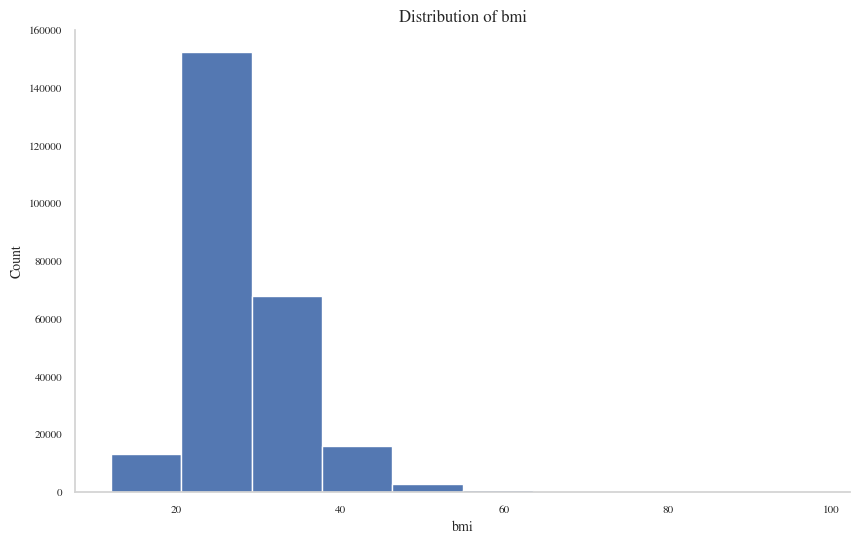

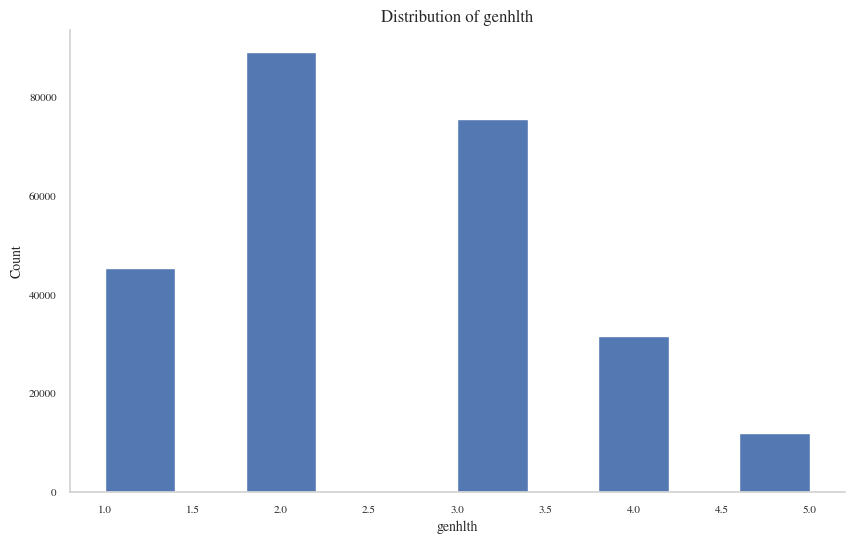

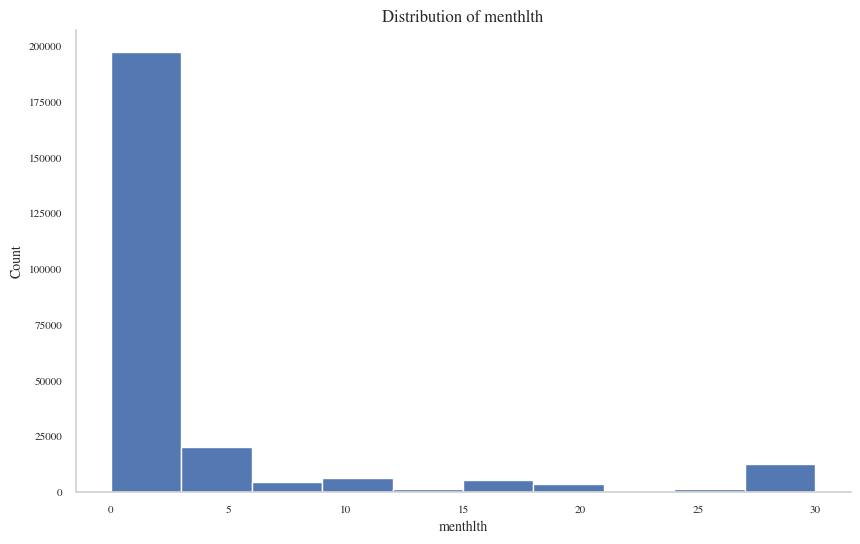

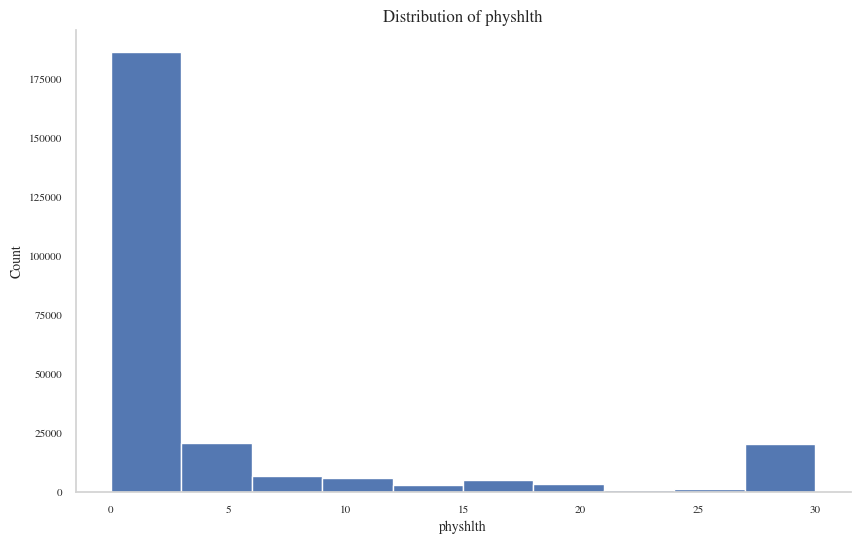

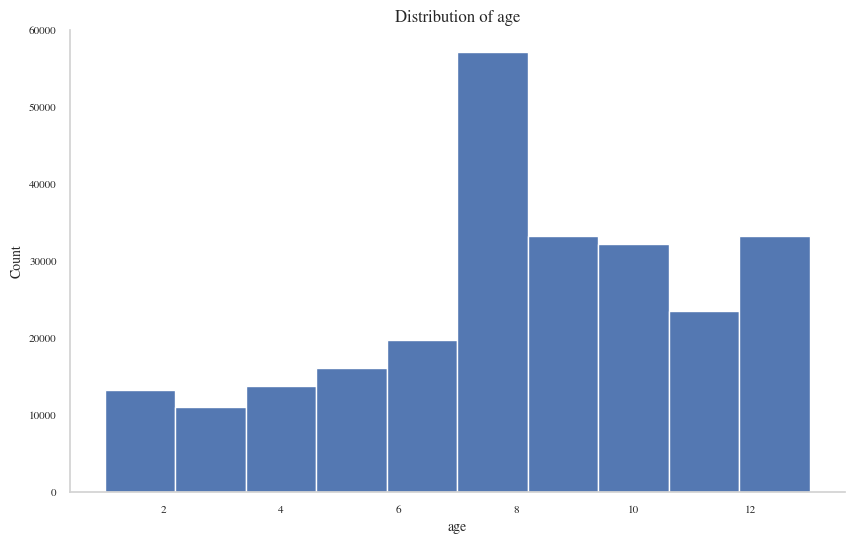

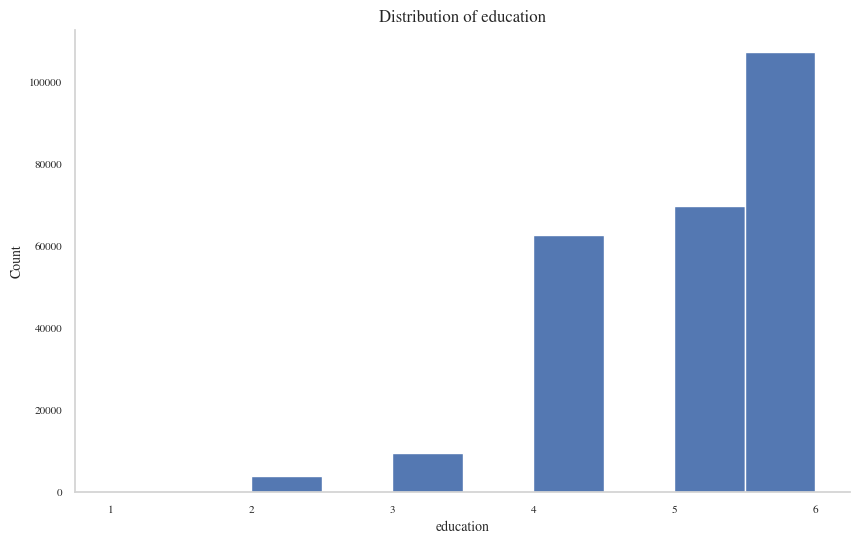

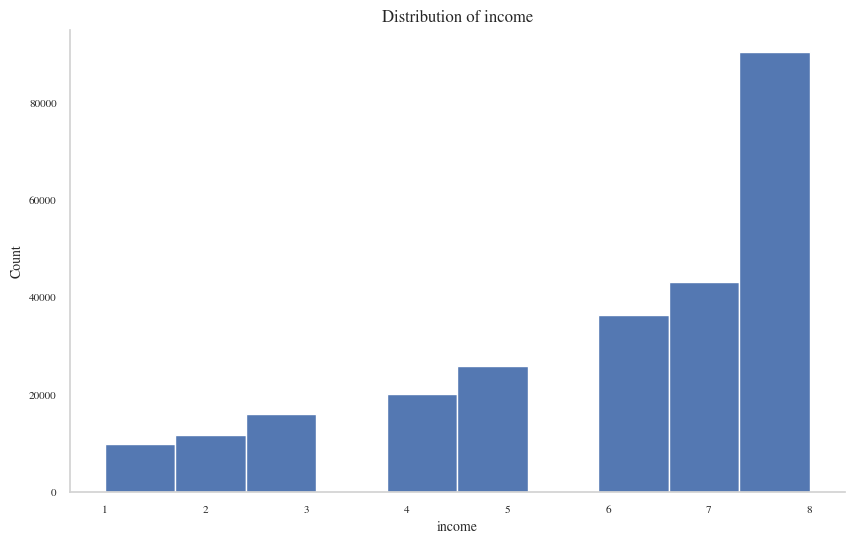

In [ ]:
#EDA of continuous variables

for col in cont_cols:
    plt.figure()
    create_histogram(
        data=data,
        x=col,
        title=f'Distribution of {col}',
        xlabel=col,
        ylabel='Count',
        bins=10,
    )
    plt.show()

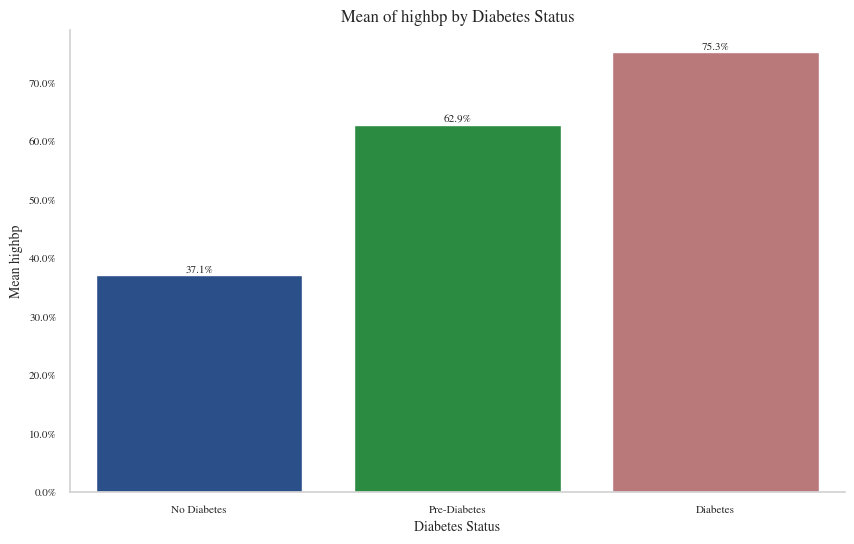

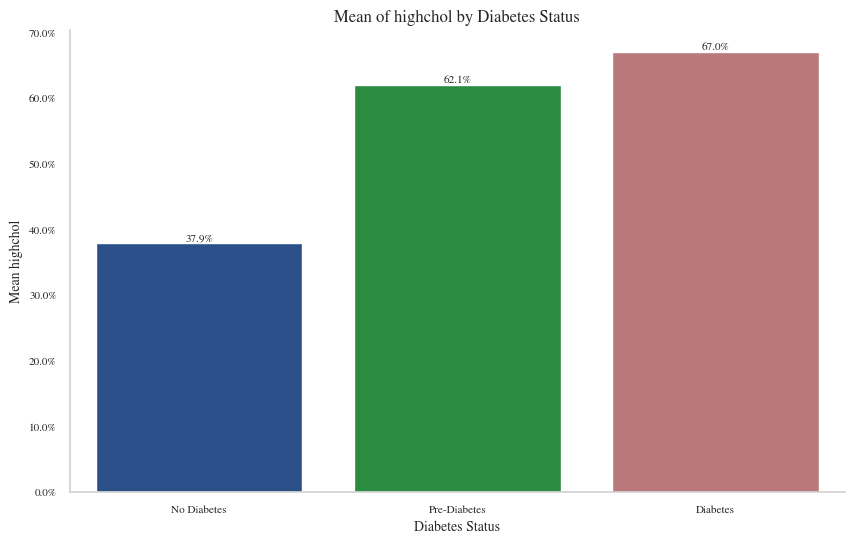

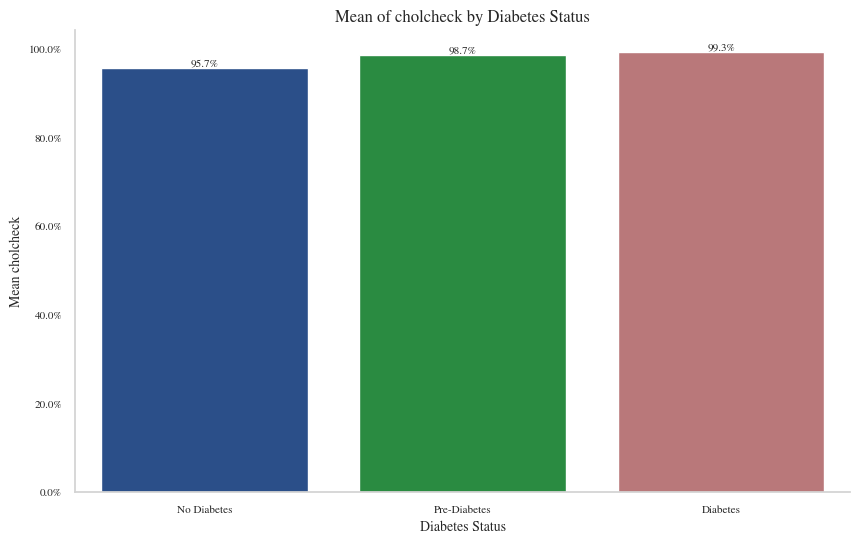

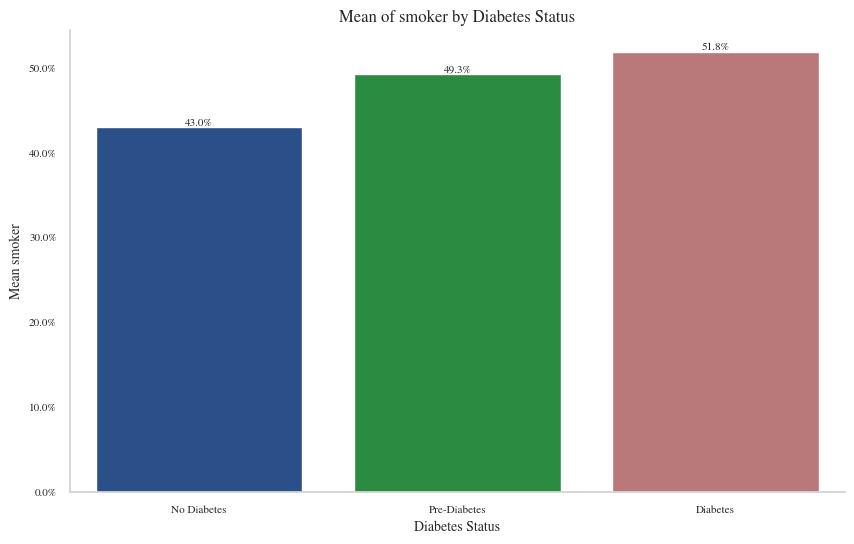

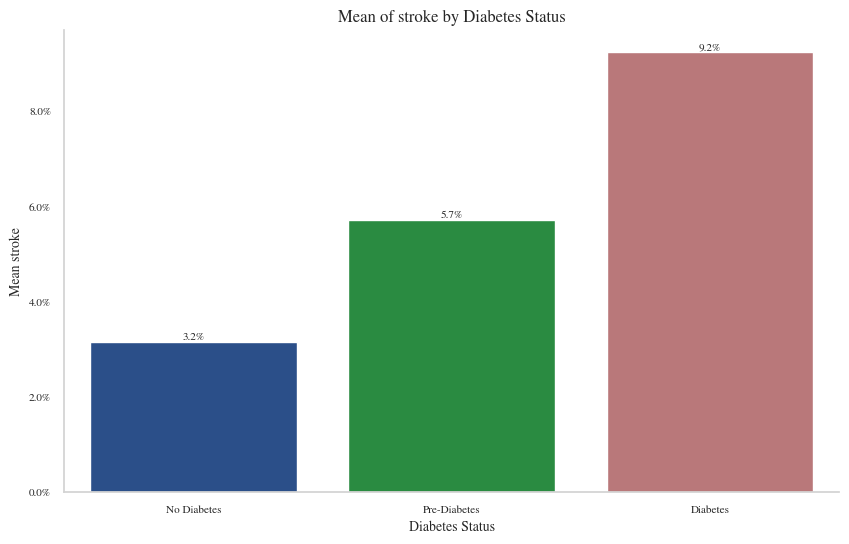

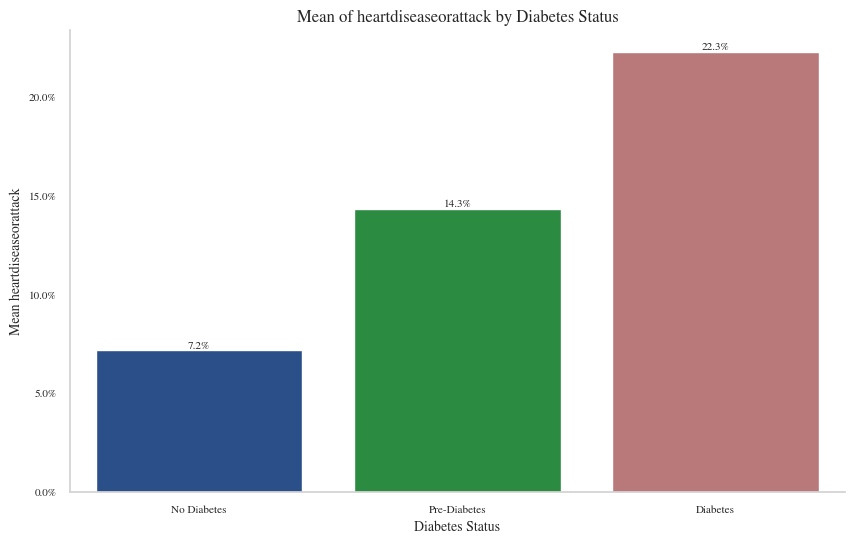

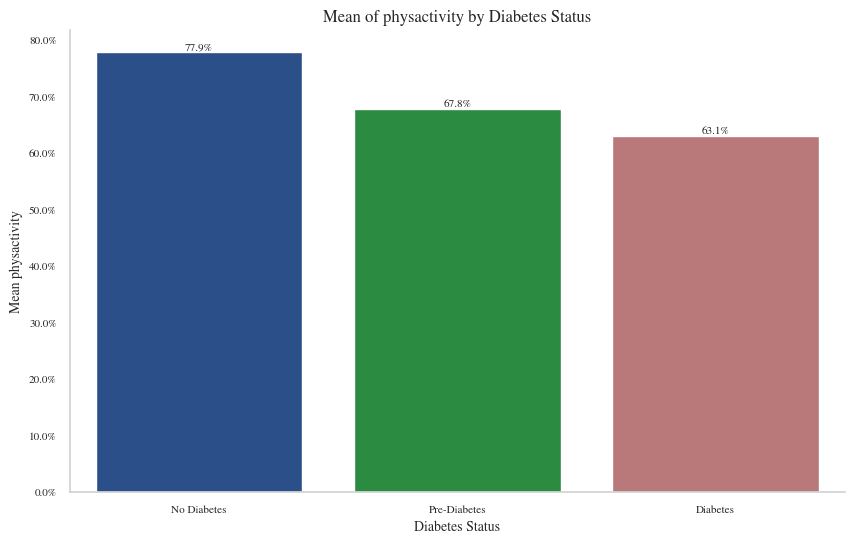

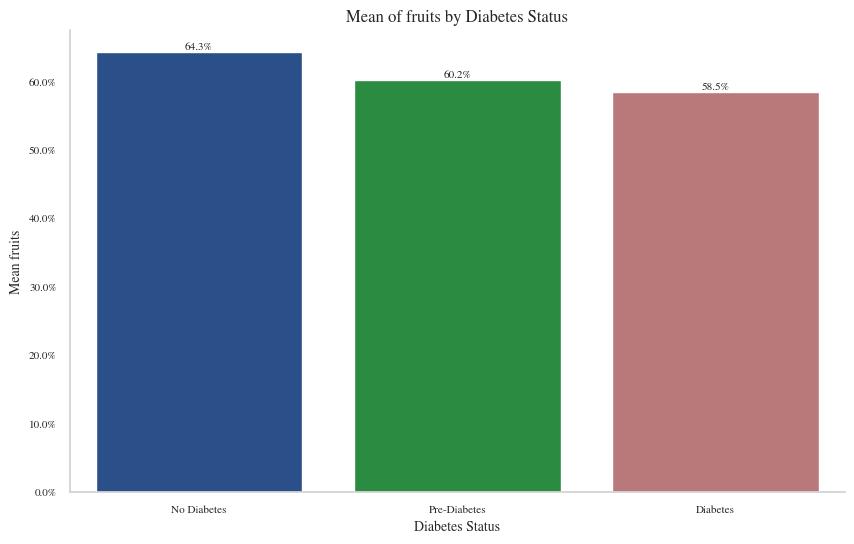

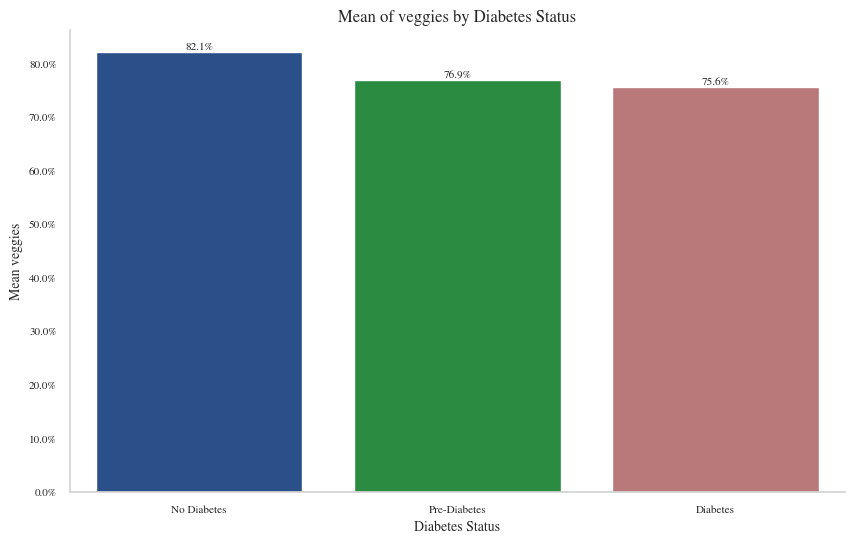

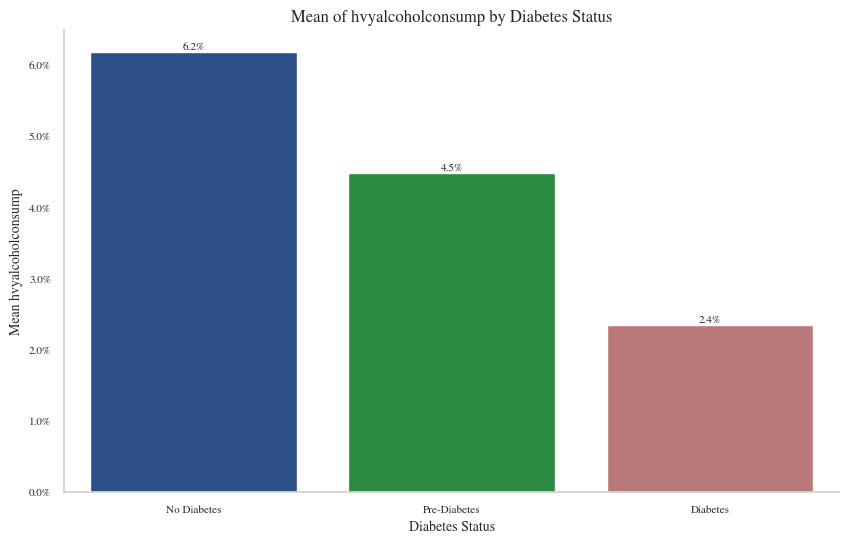

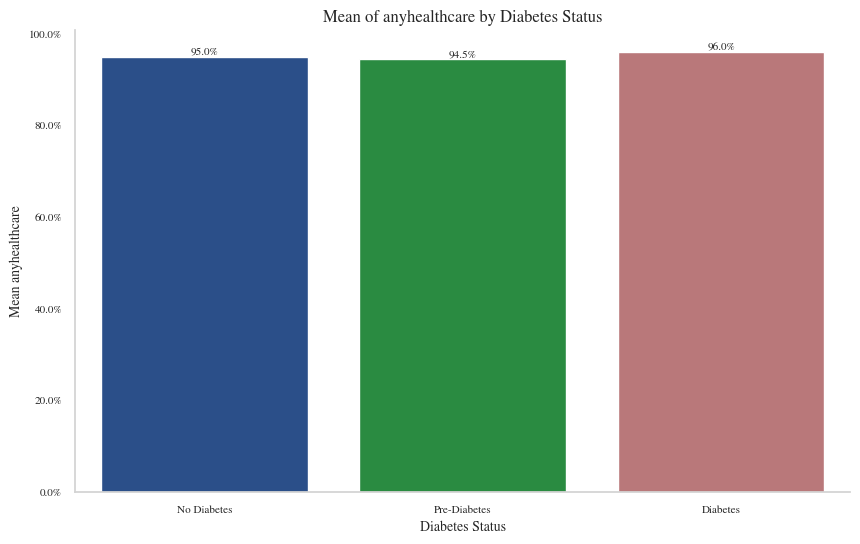

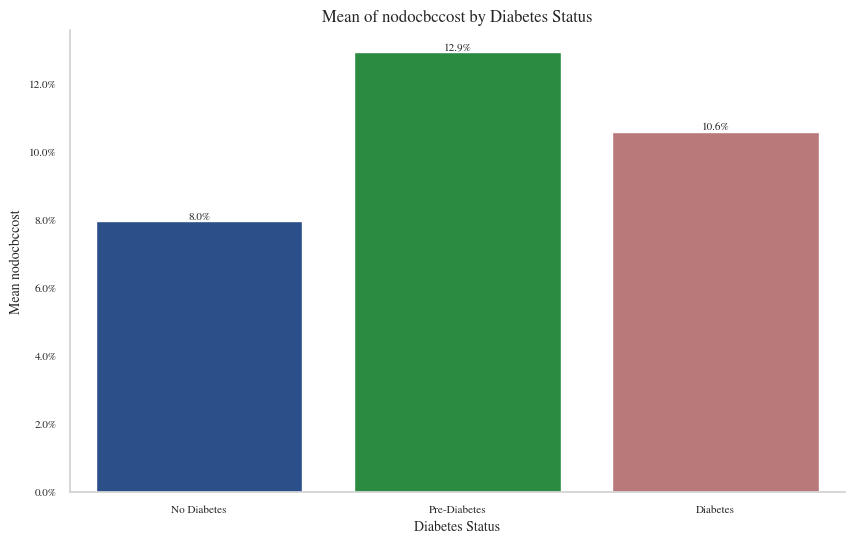

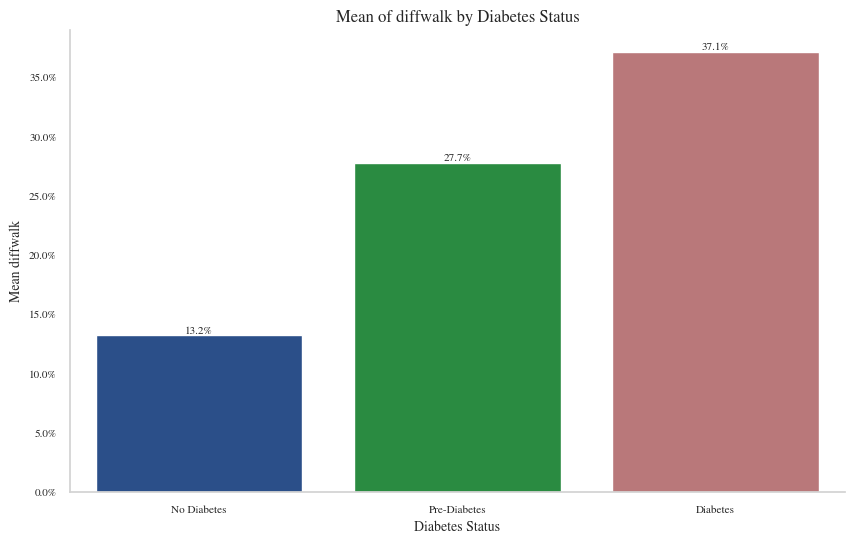

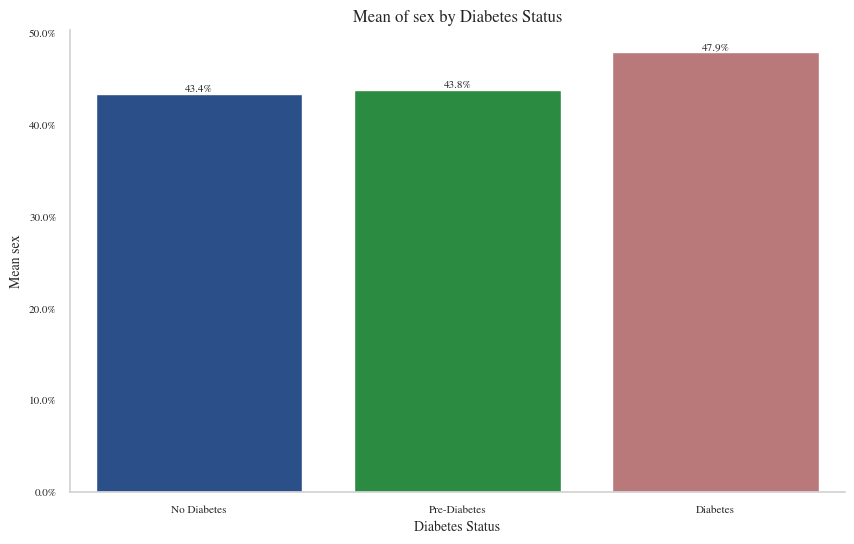

In [ ]:
#EDA for categorical variables

for col in cat_cols:
    cat_df = (data
              .groupby([target_column])[col].agg('mean')
              .reset_index()
              .replace({target_column: {0: 'No Diabetes', 1: 'Pre-Diabetes', 2: 'Diabetes'}})
            )
    plt.figure()
    create_bar_chart(
        data=cat_df,
        x=target_column,
        y=col,
        hue=target_column,
        title=f'Mean of {col} by Diabetes Status',
        xlabel='Diabetes Status',
        ylabel=f'Mean {col}',
    )
    plt.show()

In [ ]:
data.columns

Index(['diabetes_012', 'highbp', 'highchol', 'cholcheck', 'bmi', 'smoker',
       'stroke', 'heartdiseaseorattack', 'physactivity', 'fruits', 'veggies',
       'hvyalcoholconsump', 'anyhealthcare', 'nodocbccost', 'genhlth',
       'menthlth', 'physhlth', 'diffwalk', 'sex', 'age', 'education',
       'income'],
      dtype='object')